## Pre Process

In [2]:
import pandas as pd

### Import File

In [3]:
path = "C:\\Users\\DELL\\Downloads\\mlproject\\bone-cancer-detection\\data\\raw\\dataset.xlsx"
data=pd.read_excel(path)
df=pd.DataFrame(data)

In [4]:
data.tail()

,image_id,center,age,gender,hand,ulna,radius,humerus,foot,tibia,...,synovial osteochondroma,other bt,osteosarcoma,other mt,upper limb,lower limb,pelvis,frontal,lateral,oblique
3741,IMG003742.jpg,3,55,M,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
3742,IMG003743.jpg,3,55,M,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
3743,IMG003744.jpg,3,55,M,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
3744,IMG003745.jpg,3,8,M,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
3745,IMG003746.jpg,3,8,M,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0


In [5]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (3746, 37)

Columns:
['image_id', 'center', 'age', 'gender', 'hand', 'ulna', 'radius', 'humerus', 'foot', 'tibia', 'fibula', 'femur', 'hip bone', 'ankle-joint', 'knee-joint', 'hip-joint', 'wrist-joint', 'elbow-joint', 'shoulder-joint', 'tumor', 'benign', 'malignant', 'osteochondroma', 'multiple osteochondromas', 'simple bone cyst', 'giant cell tumor', 'osteofibroma', 'synovial osteochondroma', 'other bt', 'osteosarcoma', 'other mt', 'upper limb', 'lower limb', 'pelvis', 'frontal', 'lateral', 'oblique']


In [6]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
image_id                    0
center                      0
age                         0
gender                      0
hand                        0
ulna                        0
radius                      0
humerus                     0
foot                        0
tibia                       0
fibula                      0
femur                       0
hip bone                    0
ankle-joint                 0
knee-joint                  0
hip-joint                   0
wrist-joint                 0
elbow-joint                 0
shoulder-joint              0
tumor                       0
benign                      0
malignant                   0
osteochondroma              0
multiple osteochondromas    0
simple bone cyst            0
giant cell tumor            0
osteofibroma                0
synovial osteochondroma     0
other bt                    0
osteosarcoma                0
other mt                    0
upper limb                  0
lower limb              

In [7]:
df[["image_id", "tumor", "benign", "malignant"]].head(10)

,image_id,tumor,benign,malignant
0,IMG000001.jpeg,1,0,1
1,IMG000002.jpeg,1,0,1
2,IMG000003.jpeg,1,0,1
3,IMG000004.jpeg,1,0,1
4,IMG000005.jpeg,1,0,1
5,IMG000006.jpeg,1,0,1
6,IMG000007.jpeg,1,0,1
7,IMG000008.jpeg,1,0,1
8,IMG000009.jpeg,1,0,1
9,IMG000010.jpeg,1,0,1


In [8]:
print("Tumor:")
print(df["tumor"].value_counts(dropna=False))

print("\nBenign:")
print(df["benign"].value_counts(dropna=False))

print("\nMalignant:")
print(df["malignant"].value_counts(dropna=False))

Tumor:
tumor
0    1879
1    1867
Name: count, dtype: int64

Benign:
benign
0    2221
1    1525
Name: count, dtype: int64

Malignant:
malignant
0    3404
1     342
Name: count, dtype: int64


### Feature Engineering

In [9]:
print(df["malignant"].unique())

[1 0]


In [10]:
# Create binary cancer target
df["cancer"] = df["malignant"].astype(int)
# Check the new target
print(df["cancer"].value_counts())

cancer
0    3404
1     342
Name: count, dtype: int64


In [11]:
df[["image_id", "malignant", "cancer"]].head(10)

,image_id,malignant,cancer
0,IMG000001.jpeg,1,1
1,IMG000002.jpeg,1,1
2,IMG000003.jpeg,1,1
3,IMG000004.jpeg,1,1
4,IMG000005.jpeg,1,1
5,IMG000006.jpeg,1,1
6,IMG000007.jpeg,1,1
7,IMG000008.jpeg,1,1
8,IMG000009.jpeg,1,1
9,IMG000010.jpeg,1,1


In [12]:
print("No Cancer:", (df["cancer"] == 0).sum())
print("Cancer:", (df["cancer"] == 1).sum())

No Cancer: 3404
Cancer: 342


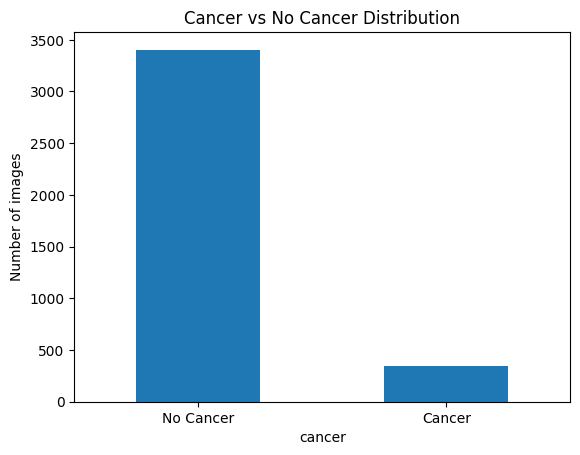

In [13]:
import matplotlib.pyplot as plt
df["cancer"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["No Cancer", "Cancer"], rotation=0)
plt.ylabel("Number of images")
plt.title("Cancer vs No Cancer Distribution")
plt.show()

### Image Processing

In [14]:
# Import Path to work with file and folder paths
from pathlib import Path

# Define the main project folder
# Using a single project path makes it easier to locate all dataset files
PROJECT_ROOT = Path(r"C:\Users\DELL\Downloads\mlproject\bone-cancer-detection")

# Define the location of the raw dataset
# Raw data is kept unchanged throughout the preprocessing process
RAW_DATA = PROJECT_ROOT / "data" / "raw"

# Define the location where processed data will eventually be saved
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"

# Define the folder containing the X-ray images
IMAGE_DIR = RAW_DATA / "images"

# Check whether the image folder actually exists
print("Image directory:", IMAGE_DIR)
print("Directory exists:", IMAGE_DIR.exists())

Image directory: C:\Users\DELL\Downloads\mlproject\bone-cancer-detection\data\raw\images
Directory exists: True


In [15]:
print("First 10 image IDs:")
print(df["image_id"].head(10).tolist())

First 10 image IDs:
['IMG000001.jpeg', 'IMG000002.jpeg', 'IMG000003.jpeg', 'IMG000004.jpeg', 'IMG000005.jpeg', 'IMG000006.jpeg', 'IMG000007.jpeg', 'IMG000008.jpeg', 'IMG000009.jpeg', 'IMG000010.jpeg']


In [16]:
# Check whether each image listed in the Excel file
# actually exists in the image folder.
df["image_path"] = df["image_id"].apply(
    lambda x: IMAGE_DIR / str(x)
)

# Check which images are present
df["image_exists"] = df["image_path"].apply(
    lambda x: x.exists()
)

# Count images that were successfully found
print("Images found:", df["image_exists"].sum())

# Count images that could not be found
print("Images missing:", (~df["image_exists"]).sum())

Images found: 3746
Images missing: 0


In [17]:
# Display a few examples showing the connection
# between the Excel image ID and the actual file path.
df[["image_id", "image_path", "image_exists"]].head(10)

,image_id,image_path,image_exists
0,IMG000001.jpeg,C:\Users\DELL\Downloads\mlproject\bone-cancer-...,True
1,IMG000002.jpeg,C:\Users\DELL\Downloads\mlproject\bone-cancer-...,True
2,IMG000003.jpeg,C:\Users\DELL\Downloads\mlproject\bone-cancer-...,True
3,IMG000004.jpeg,C:\Users\DELL\Downloads\mlproject\bone-cancer-...,True
4,IMG000005.jpeg,C:\Users\DELL\Downloads\mlproject\bone-cancer-...,True
5,IMG000006.jpeg,C:\Users\DELL\Downloads\mlproject\bone-cancer-...,True
6,IMG000007.jpeg,C:\Users\DELL\Downloads\mlproject\bone-cancer-...,True
7,IMG000008.jpeg,C:\Users\DELL\Downloads\mlproject\bone-cancer-...,True
8,IMG000009.jpeg,C:\Users\DELL\Downloads\mlproject\bone-cancer-...,True
9,IMG000010.jpeg,C:\Users\DELL\Downloads\mlproject\bone-cancer-...,True


### 3.1 Inspecting Image Dimensions

In [18]:
#check the original image sizes before preprocessing. This helps us decide on a common size for all images.

In [19]:
# Pillow is used to open and inspect image files
from PIL import Image

In [20]:
# Inspect the dimensions of the original BTXRD images

from PIL import Image

# Get paths for images that actually exist
existing_images = df.loc[df["image_exists"], "image_path"]

# Read image dimensions
image_sizes = []

for image_path in existing_images:
    try:
        with Image.open(image_path) as img:
            image_sizes.append(img.size)
    except Exception as e:
        print(f"Could not read {image_path}: {e}")

# Display basic information
print(f"Images checked: {len(image_sizes)}")

if image_sizes:
    print(f"First image size: {image_sizes[0]}")
    print(f"Unique image sizes: {len(set(image_sizes))}")

Images checked: 3746
First image size: (3213, 2397)
Unique image sizes: 3148


In [21]:
# Check image aspect ratios before resizing

aspect_ratios = []

for image_path in existing_images:
    try:
        with Image.open(image_path) as img:
            width, height = img.size
            aspect_ratios.append(width / height)
    except Exception:
        pass

print(f"Minimum aspect ratio: {min(aspect_ratios):.3f}")
print(f"Maximum aspect ratio: {max(aspect_ratios):.3f}")
print(f"Average aspect ratio: {sum(aspect_ratios) / len(aspect_ratios):.3f}")

Minimum aspect ratio: 0.218
Maximum aspect ratio: 2.856
Average aspect ratio: 0.801


In [22]:
# Inspect the distribution of image aspect ratios

import numpy as np

aspect_ratios_np = np.array(aspect_ratios)

print("Aspect ratio statistics:")
print(f"Minimum: {np.min(aspect_ratios_np):.3f}")
print(f"25th percentile: {np.percentile(aspect_ratios_np, 25):.3f}")
print(f"Median: {np.median(aspect_ratios_np):.3f}")
print(f"75th percentile: {np.percentile(aspect_ratios_np, 75):.3f}")
print(f"Maximum: {np.max(aspect_ratios_np):.3f}")

Aspect ratio statistics:
Minimum: 0.218
25th percentile: 0.624
Median: 0.764
75th percentile: 0.903
Maximum: 2.856


In [23]:
# Find images with the most unusual aspect ratios

ratio_df = df.loc[df["image_exists"], ["image_id", "image_path"]].copy()

def get_aspect_ratio(image_path):
    # Read image dimensions without modifying the image
    with Image.open(image_path) as img:
        width, height = img.size
    return width / height

ratio_df["aspect_ratio"] = ratio_df["image_path"].apply(get_aspect_ratio)

# Get the 5 narrowest and 5 widest images
narrowest = ratio_df.nsmallest(5, "aspect_ratio")
widest = ratio_df.nlargest(5, "aspect_ratio")

print("Narrowest images:")
display(narrowest[["image_id", "aspect_ratio"]])

print("\nWidest images:")
display(widest[["image_id", "aspect_ratio"]])

Narrowest images:


,image_id,aspect_ratio
3672,IMG003673.jpeg,0.218391
3611,IMG003612.jpeg,0.273381
2712,IMG002713.jpeg,0.290357
3546,IMG003547.jpeg,0.298767
3547,IMG003548.jpeg,0.308906



Widest images:


,image_id,aspect_ratio
1613,IMG001614.jpeg,2.855670
3164,IMG003165.jpeg,2.715447
3622,IMG003623.jpeg,2.641975
1378,IMG001379.jpeg,2.516833
3523,IMG003524.jpeg,2.501425


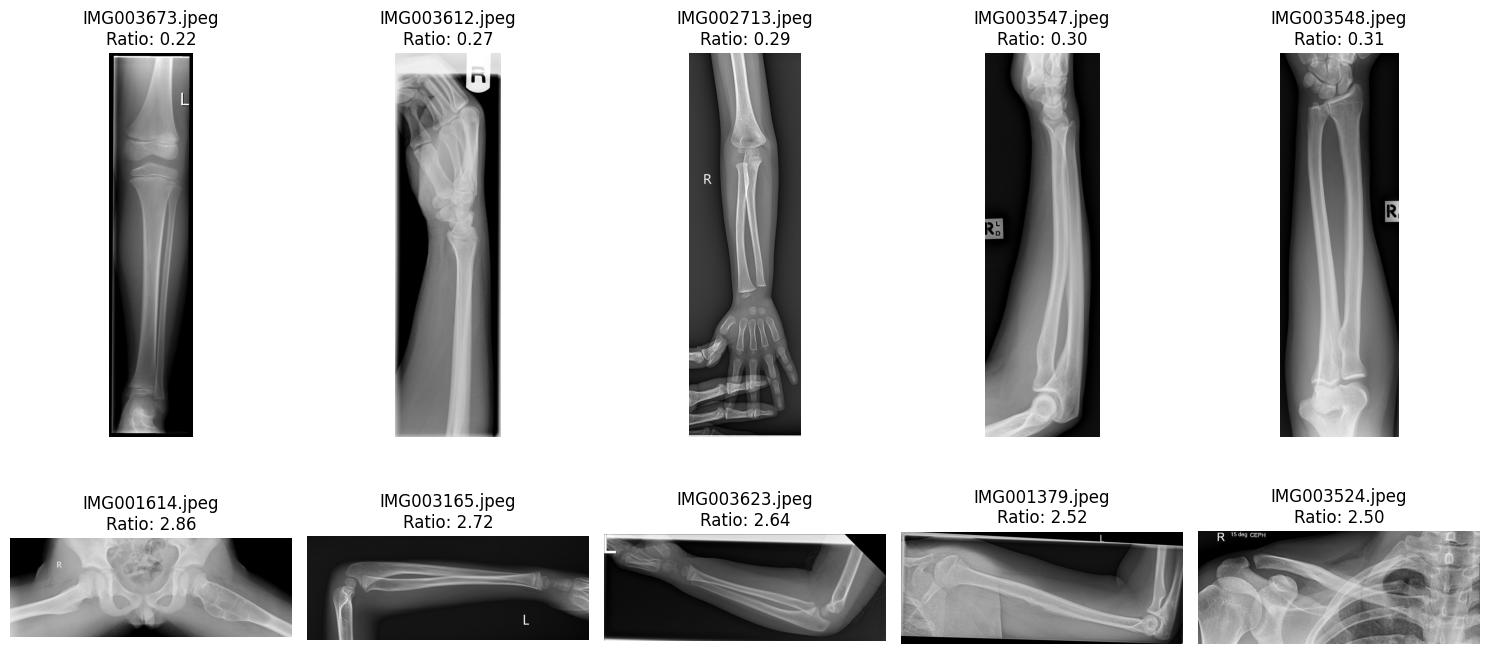

In [24]:
# Display images with the most extreme aspect ratios

import matplotlib.pyplot as plt

extreme_images = pd.concat([
    narrowest,
    widest
])

fig, axes = plt.subplots(2, 5, figsize=(15, 8))

for ax, (_, row) in zip(axes.ravel(), extreme_images.iterrows()):
    with Image.open(row["image_path"]) as img:
        ax.imshow(img, cmap="gray")
    
    ax.set_title(
        f'{row["image_id"]}\nRatio: {row["aspect_ratio"]:.2f}'
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

### 3.2 Image Resizing

Images have different dimensions and aspect ratios, so they are resized to a consistent 224 × 224 size while preserving their original proportions. Padding is added where necessary to avoid distortion.

In [25]:
# Define the target image size

TARGET_SIZE = (224, 224)

print(f"Target image size: {TARGET_SIZE}")

Target image size: (224, 224)


In [32]:
# Function to resize an X-ray while preserving its aspect ratio

def resize_image(image_path, target_size=(224, 224)):
    # Open the image
    with Image.open(image_path) as img:

        # Correct orientation stored in EXIF metadata
        img = ImageOps.exif_transpose(img)

        # Convert to RGB
        img = img.convert("RGB")

        # Resize while preserving aspect ratio and add padding
        img = ImageOps.pad(
            img,
            target_size,
            method=Image.Resampling.LANCZOS,
            color=(0, 0, 0),
            centering=(0.5, 0.5)
        )

        return img

In [33]:
# Test aspect-ratio-preserving resizing on a few images

from PIL import ImageOps

# Select a few images with different aspect ratios
test_images = [
    narrowest.iloc[0]["image_path"],
    widest.iloc[0]["image_path"],
    existing_images.iloc[0]
]

for image_path in test_images:
    with Image.open(image_path) as img:
        # Correct any orientation stored in EXIF metadata
        img = ImageOps.exif_transpose(img)

        # Convert to RGB for compatibility with CNN models
        img = img.convert("RGB")

        # Resize while preserving aspect ratio and pad to 224x224
        resized = ImageOps.pad(
            img,
            TARGET_SIZE,
            method=Image.Resampling.LANCZOS,
            color=(0, 0, 0),
            centering=(0.5, 0.5)
        )

        print(
            f"{Path(image_path).name}: "
            f"{img.size} -> {resized.size}"
        )

IMG003673.jpeg: (456, 2088) -> (224, 224)
IMG001614.jpeg: (1385, 485) -> (224, 224)
IMG000001.jpeg: (3213, 2397) -> (224, 224)


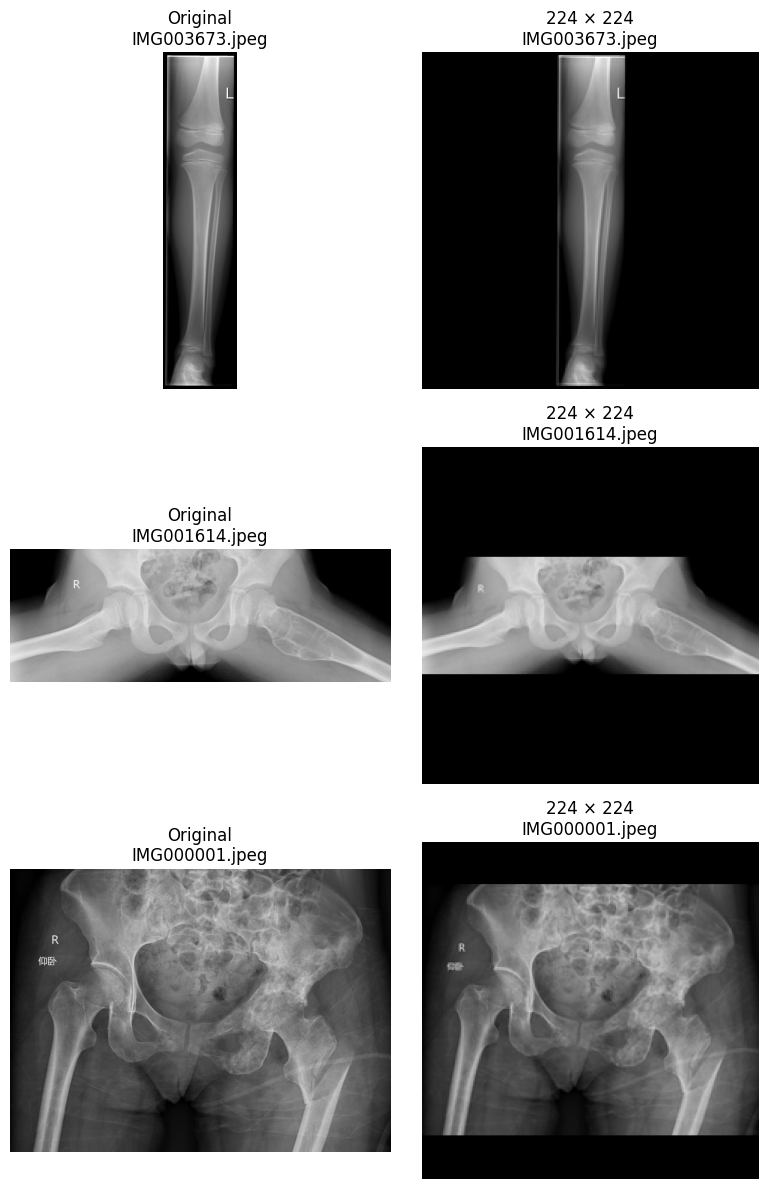

In [34]:
# Visually compare original images with their resized versions

import matplotlib.pyplot as plt
from PIL import ImageOps

fig, axes = plt.subplots(
    len(test_images), 2,
    figsize=(8, 12)
)

for i, image_path in enumerate(test_images):

    with Image.open(image_path) as img:
        # Keep the original for comparison
        original = ImageOps.exif_transpose(img).convert("RGB")

        # Resize while preserving aspect ratio
        processed = ImageOps.pad(
            original,
            TARGET_SIZE,
            method=Image.Resampling.LANCZOS,
            color=(0, 0, 0),
            centering=(0.5, 0.5)
        )

    # Original image
    axes[i, 0].imshow(original)
    axes[i, 0].set_title(
        f"Original\n{Path(image_path).name}"
    )
    axes[i, 0].axis("off")

    # Processed image
    axes[i, 1].imshow(processed)
    axes[i, 1].set_title(
        f"224 × 224\n{Path(image_path).name}"
    )
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

The resizing method preserves the original aspect ratio and adds padding to create a consistent 224 × 224 image size. The original BTXRD images remain unchanged.

In [35]:
# Create the folder for processed images

PROCESSED_IMAGE_DIR = PROCESSED_DATA / "images"
PROCESSED_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Processed image directory: {PROCESSED_IMAGE_DIR}")

Processed image directory: C:\Users\DELL\Downloads\mlproject\bone-cancer-detection\data\processed\images


In [36]:
# Resize and save all BTXRD images

processed_count = 0
failed_images = []

for _, row in df[df["image_exists"]].iterrows():
    image_path = row["image_path"]
    output_path = PROCESSED_IMAGE_DIR / row["image_id"]

    try:
        # Resize while preserving aspect ratio and adding padding
        processed_image = resize_image(
            image_path,
            TARGET_SIZE
        )

        # Save as PNG to avoid additional JPEG compression
        output_path = output_path.with_suffix(".png")
        processed_image.save(output_path, format="PNG")

        processed_count += 1

    except Exception as e:
        failed_images.append({
            "image_id": row["image_id"],
            "error": str(e)
        })

print(f"Images processed successfully: {processed_count}")
print(f"Images failed: {len(failed_images)}")

Images processed successfully: 3746
Images failed: 0


In [37]:
# Inspect the first few processing errors

print(f"Total failed images: {len(failed_images)}")

for error in failed_images[:10]:
    print(error)

Total failed images: 0


In [38]:
# Test the resizing function

test_path = df.loc[df["image_exists"], "image_path"].iloc[0]

processed_image = resize_image(
    test_path,
    TARGET_SIZE
)

print("Original size:", Image.open(test_path).size)
print("Processed size:", processed_image.size)

Original size: (3213, 2397)
Processed size: (224, 224)


In [40]:
# Verify the processed images

processed_files = list(PROCESSED_IMAGE_DIR.glob("*.png"))

print(f"Processed images found: {len(processed_files)}")

Processed images found: 3746


In [41]:
# Verify the dimensions of a few processed images

for image_path in processed_files[:5]:
    with Image.open(image_path) as img:
        print(f"{image_path.name}: {img.size}")

IMG000001.png: (224, 224)
IMG000002.png: (224, 224)
IMG000003.png: (224, 224)
IMG000004.png: (224, 224)
IMG000005.png: (224, 224)


# 4. Dataset Preparation

The dataset is split into training, validation, and test sets. Augmentation will be applied only to the training set to prevent data leakage.

In [42]:
# Prepare metadata for the processed dataset

processed_df = df[[
    "image_id",
    "cancer"
]].copy()

# Point each image to its processed 224 × 224 PNG
processed_df["image_path"] = processed_df["image_id"].apply(
    lambda x: PROCESSED_IMAGE_DIR / Path(x).with_suffix(".png").name
)

# Verify the processed files exist
processed_df["processed_exists"] = processed_df["image_path"].apply(
    lambda x: x.exists()
)

print("Total images:", len(processed_df))
print("Processed images found:", processed_df["processed_exists"].sum())
print("Processed images missing:", (~processed_df["processed_exists"]).sum())

Total images: 3746
Processed images found: 3746
Processed images missing: 0


In [43]:
# Create metadata for the processed BTXRD images

processed_metadata = processed_df[[
    "image_id",
    "cancer",
    "image_path"
]].copy()

# Save the metadata inside the processed data folder
metadata_path = PROCESSED_DATA / "BTXRD_processed_metadata.csv"

processed_metadata.to_csv(
    metadata_path,
    index=False
)

print(f"Metadata saved to: {metadata_path}")
print(f"Records: {len(processed_metadata)}")

Metadata saved to: C:\Users\DELL\Downloads\mlproject\bone-cancer-detection\data\processed\BTXRD_processed_metadata.csv
Records: 3746
